# we've not been exping log p_true

---> nice! none of our metrics care about this

In [1]:
%load_ext autoreload
%autoreload 2

import os
os.chdir('../..')
import pickle
import yaml
import json

from matplotlib import pyplot as plt
import pandas as pd
import numpy as np


from copy import deepcopy
import seaborn as sns

import wandb
api = wandb.Api()
api.entity = 'goatml'

In [2]:
# export to eval file
def get_vals(x):
    return x['mean'], x['mean']-x['bootstrap']['std_err'], x['mean']+x['bootstrap']['std_err']

def get_vals2(x):
    return x['means'], x['low'], x['high']


def get_perfs(metrics):
    data = []
    for method in metrics['performance']:
        mean, low, high = get_vals(metrics['performance'][method])
        data.append([method, mean, low, high])
    
    df = pd.DataFrame(data, columns=['method', 'means', 'low', 'high'])
    return df.set_index('method')

def plot_bar(df, color='C0', ax=None):
    if ax is None:
        fig, ax = plt.subplots()

    df.plot.bar(y='means', yerr=[df.means - df.low, df.high - df.means], color=color, ax=ax)

def get_uncertainty_df(metrics):
    data = []
    for method in metrics['uncertainty']:
        for metric in metrics['uncertainty'][method]:
            mean, low, high = get_vals(metrics['uncertainty'][method][metric])
            data.append([method, metric, mean, low, high])
    
    df = pd.DataFrame(data, columns=['method', 'metric', 'means', 'low', 'high'])
    
    df = df.set_index('method')

    def get_base_method(x):
        if 'p_false' in x:
            return 'p_false'
        elif 'p_ik' in x:
            return 'p_ik'
        elif 'regular_entropy' in x:
            return 'regular_entropy'
        elif 'cluster_assignment' in x:
            return x
        elif 'semantic_entropy' in x:
            return 'semantic_entropy'
        else:
            raise
    df['base_method'] = df.index.map(get_base_method)
    return df

def plot_bar_uncertainty(pdf, metric, remove='_UNANSWERABLE', ax=None):
    if ax is None:
        fig, ax = plt.subplots()

    tmp = pdf
    # filter out unanswerable
    if remove is not None:
        tmp = tmp[tmp.index.map(lambda x: remove not in x)]
    tmp = tmp.reset_index()
    tmp = tmp.set_index('metric').loc[metric]
    tmp = tmp.set_index('method')
    tmp = tmp.sort_values('base_method')

    b2c = {m:f'C{i}' for i, m in enumerate(tmp.base_method.unique())}
    basemethod2color = lambda x: b2c[x]

    plot_bar(tmp, color=tmp.base_method.map(basemethod2color), ax=ax)
    ax.grid(axis='y', zorder=-10, alpha=0.3)

get_cfg = lambda dictionary: {k: v['value'] for k, v in dictionary.items() if isinstance(v, dict) and k != '_wandb'}
def get_diff(xk, yk):

    x, y = all_configs[xk], all_configs[yk]
    print(20*' ' + f'{runs[xk]:<20} {runs[yk]}')
    diffs = set(get_cfg(x).items()) ^ set(get_cfg(y).items())
    diffs = set([k for k, v in diffs])
    for k in diffs:
        print(f'{k:<20} {get_cfg(x).get(k, "missing"):<20} {get_cfg(y).get(k, "missing")}')
    print(80 * '-')


In [3]:
def restore_file(wandb_id, filenames=['wandb-summary.json', 'config.yaml']):
    files_dir = 'notebooks/restored_files'    
    os.system(f'mkdir -p {files_dir}')

    run = api.run(f'goatml/semantic_uncertainty/{wandb_id}')
    # run = api.run(f'goatml/uncertainty/{wandb_id}')
    out = []

    for filename in filenames:
        
        path = f'{files_dir}/{filename}'
        os.system(f'rm -rf {path}')
        run.file(filename).download(root=files_dir, replace=True, exist_ok=False)
    
        if filename.endswith('.pkl'):
            with open(path, 'rb') as f:
                out.append(pickle.load(f))
        elif filename.endswith('.yaml'):
            with open(path, 'r') as f:
                out.append(yaml.safe_load(f))
        elif filename.endswith('.json'):
            with open(path, 'r') as f:
                out.append(json.load(f))
        else:
            raise

    return out

Questions

* Which (strict/lax, deberta/gpt/llama) gives best performance on average?
* Make a table that is [strictness, entailment] with auroc!

In [4]:
# The new runs are doing strict entailment _and_ condition on question,
runs = {
    'ooslwgb9': '70b-squad-p_false',
    'rs61j0ah': '70b-squad-p_false_fixed',
    'au7s3uxg': '70b-trivia_qa-p_false',
    'abil2taf': '70b-trivia_qa-p_false_fixed',
    #
    'e5ptgcwr': '70b-bioasq-p_false',
    'm4qbtpax': '70b-bioasq-p_false_fixed',
}



all_configs, all_results = {}, {}

for wandb_id in runs:
    all_results[wandb_id], all_configs[wandb_id] = restore_file(wandb_id)


In [5]:
# get_diff('au7s3uxg', '4g1egsbm')

Can we improve accuracy by instead voting the answer from the (high-temperature) clusters?

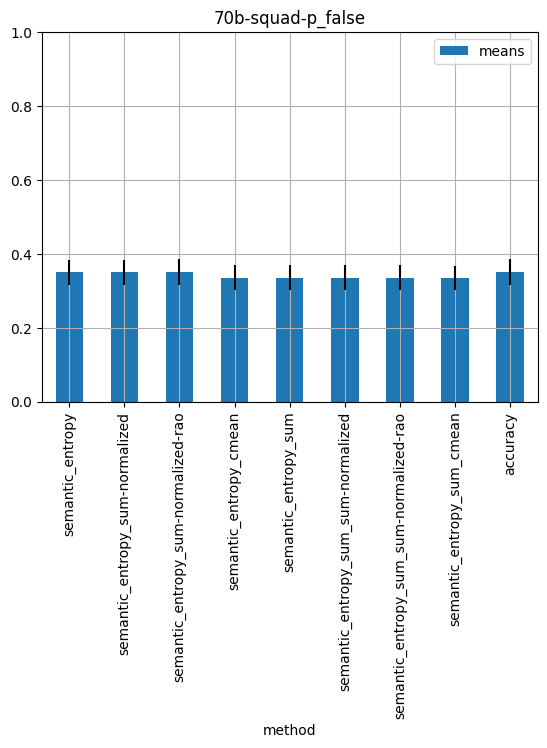

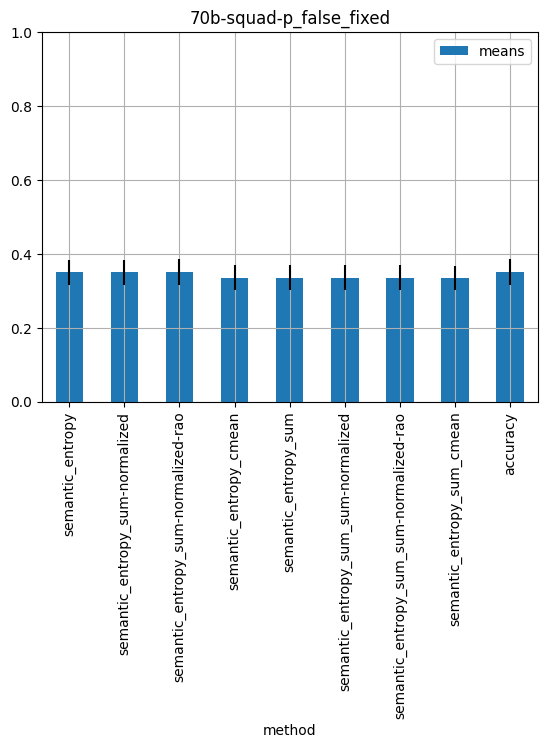

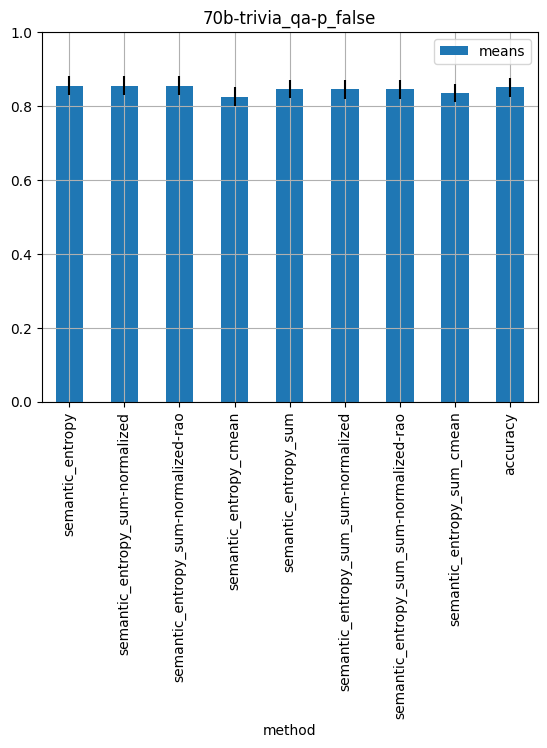

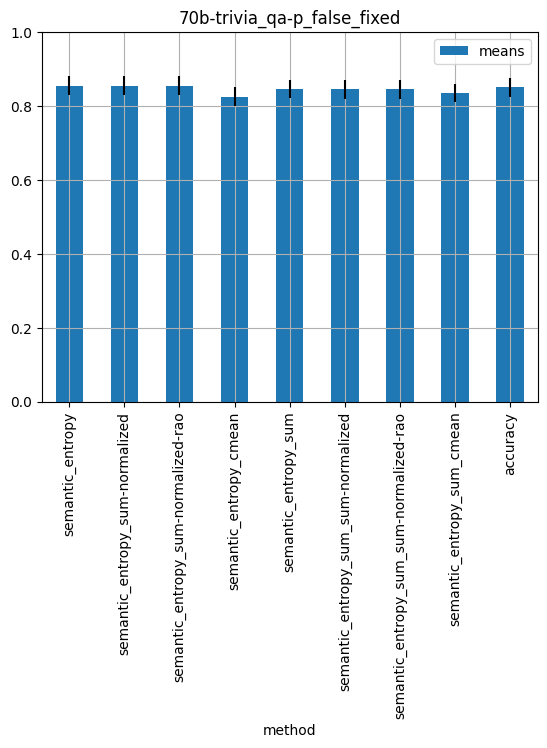

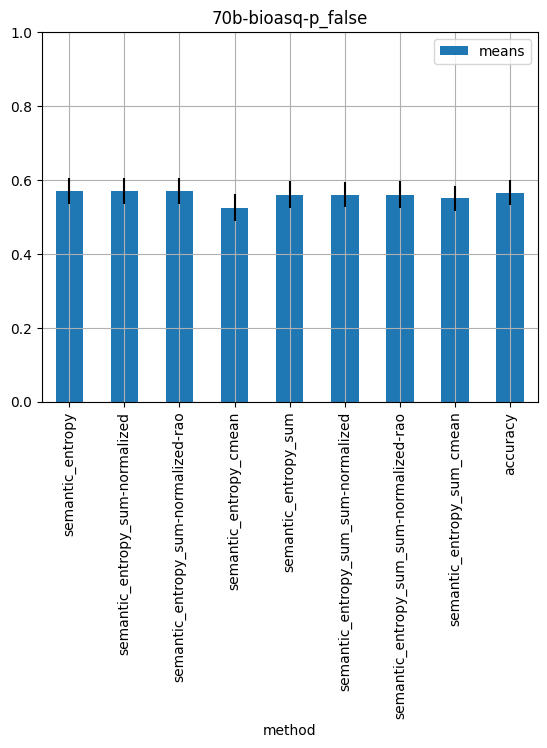

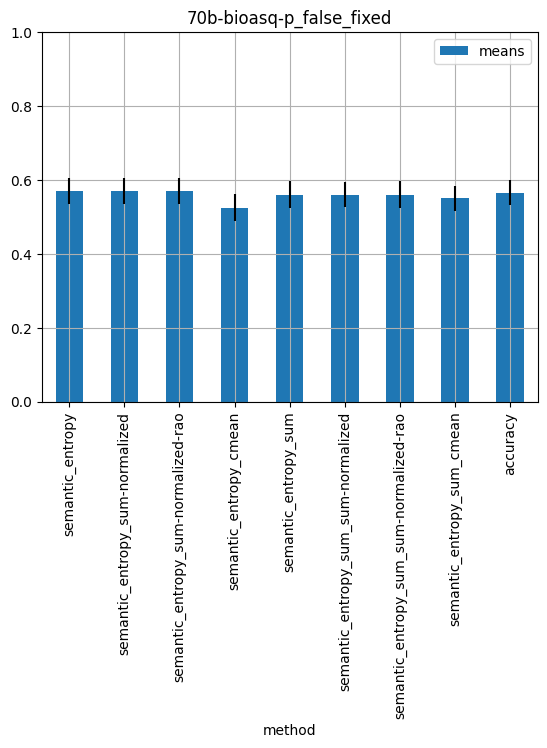

In [6]:
for wandb_id, run_name in runs.items():
    config = all_configs[wandb_id]
    results = all_results[wandb_id]

    df = get_perfs(results)
    plot_bar(df)
    plt.gca().set_title(run_name)
    plt.gca().grid()
    plt.gca().set_ylim(0, 1)


In [7]:
perfdf = {}
for wandb_id, run_name in runs.items():
    results = all_results[wandb_id]    
    perfdf[wandb_id] = get_perfs(results)

runids = list(perfdf.keys())
tmp = pd.DataFrame(perfdf[runids[0]])
tmp['run'] = runs[runids[0]]

for runid in runids[1:]:
    tmp2 = pd.DataFrame(perfdf[runid])
    tmp2['run'] = runs[runid]
    
    tmp = pd.concat([tmp, tmp2])

perfdf = tmp.reset_index()

Text(0, 0.5, 'accuracy')

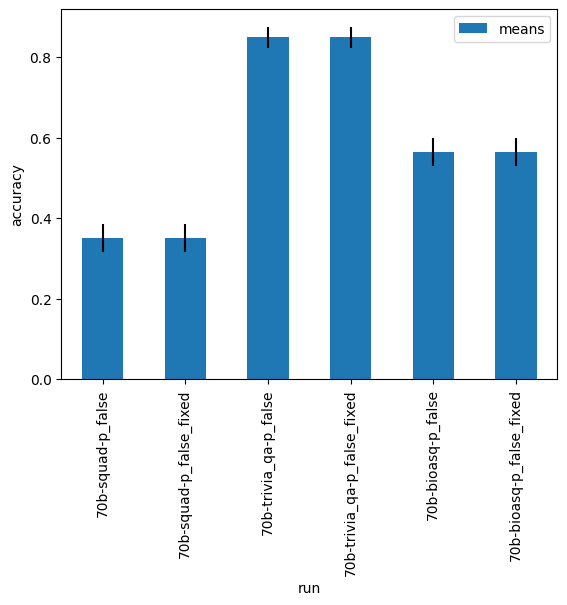

In [8]:
plot_bar(perfdf.set_index('method').loc['accuracy'].set_index('run'))
plt.gca().set_ylabel('accuracy')

In [9]:
tmp = perfdf.set_index('method').loc['accuracy']
tmp['model'] = tmp.run.map(lambda x: '-'.join(x.split('-')[:2]))
tmp['dataset'] = tmp.run.map(lambda x: '-'.join(x.split('-')[2:]))
tmp.pivot(columns='model', index='dataset', values='means')

model,70b-bioasq,70b-squad,70b-trivia_qa
dataset,,,
p_false,0.565,0.35,0.85
p_false_fixed,0.565,0.35,0.85


* 7b largely performs very similar to 70b, usually a little worse (5-10%)
* Only big difference is for trivia-qa, where removing context leads to ~20 percent accuracy hit from ~85 to ~65 (this is not necessarily bad for us though)


In [10]:
metric_names = [
    'AUROC',
    'area_under_thresholded_accuracy',
    'mean_uncertainty',
    'accuracy_at_0.8_answer_fraction',
    'accuracy_at_0.9_answer_fraction',
    'accuracy_at_0.95_answer_fraction'
]

pdfs = {}
for wandb_id in runs:
    results = all_results[wandb_id]
    pdfs[wandb_id] = get_uncertainty_df(results)

In [11]:
# fig, axes_2d = plt.subplots(len(metric_names), len(runs), sharex=True, figsize=(15, 15), dpi=100)
# # fig.suptitle(config['dataset']['value'] + ' '+ plt.gca().get_title())
# for k, (name, axes) in enumerate(zip(list(metric_names), axes_2d)):

#     for i, (ax, wandb_id) in enumerate(zip(axes, runs)):
#         plot_bar_uncertainty(pdfs[wandb_id], name, ax=ax)

#         if i == 0:
#             ax.set_ylabel(name, fontsize=8, rotation=0, ha='right')

#         if k == 0:
#             ax.set_title(runs[wandb_id])


# plt.tight_layout()
# plt.subplots_adjust(wspace=0.1, hspace=0.1)

In [12]:
runids = list(pdfs.keys())

tmp = pd.DataFrame(pdfs[runids[0]])
tmp['run'] = runs[runids[0]]

for runid in runids[1:]:
    tmp2 = pd.DataFrame(pdfs[runid])
    tmp2['run'] = runs[runid]
    
    tmp = pd.concat([tmp, tmp2])

all_runs = tmp.reset_index()

/tmp/ipykernel_987668/1764243749.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
/tmp/ipykernel_987668/1764243749.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


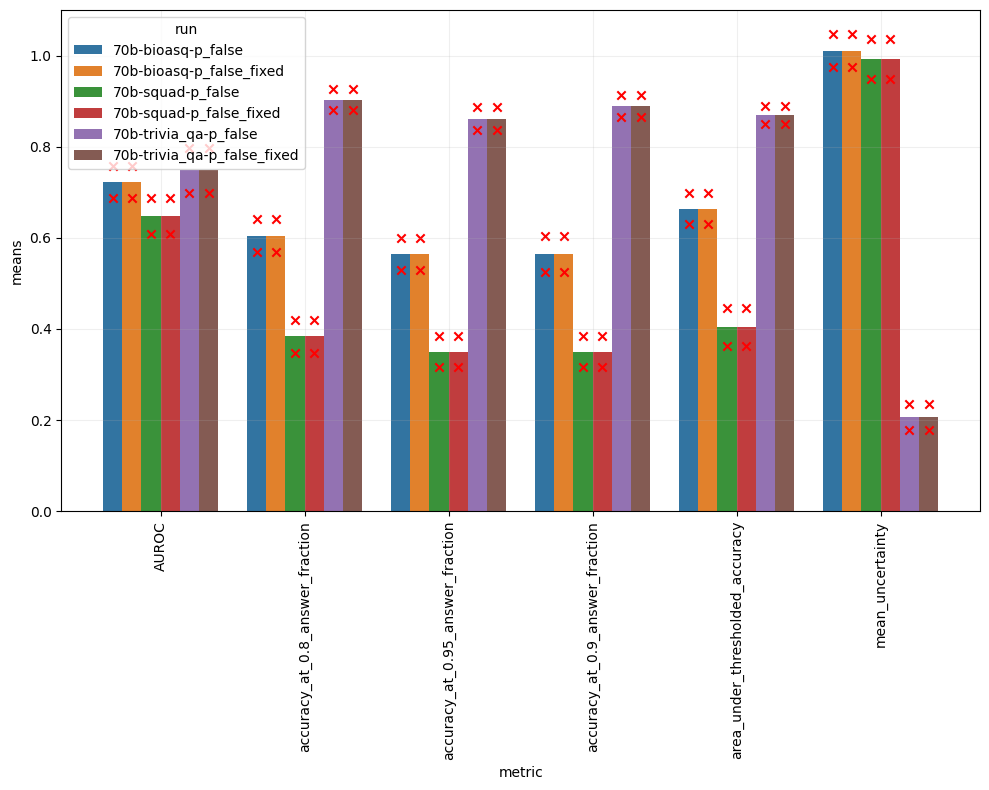

In [13]:
df2 = deepcopy(all_runs)
df2 = df2[all_runs.method == 'cluster_assignment_entropy']
df2 = df2.sort_values(['run', 'metric'])

fig, ax = plt.subplots(1, 1, figsize=(10, 8), sharey=True, dpi=100)

g = sns.barplot(
    x="metric",       # x variable name
    y="means",       # y variable name
    hue="run",  # group variable name
    data=df2,     # dataframe to plot
    ax=ax,
)

# https://stackoverflow.com/questions/72352491/how-to-plot-errorbars-on-seaborn-barplot
x_coords = [p.get_x() + 0.5 * p.get_width() for p in ax.patches]
y_coords = [p.get_height() for p in ax.patches]

for kind in ['low', 'high']:
    tmp = df2[kind].values
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    ax.scatter(x_coords[:-len(df2.run.unique())], tmp, c='red', marker='x')
ax.grid(zorder=-100, alpha=0.2)
# ax.set_ylim(0.3, 1)
plt.tight_layout()

/tmp/ipykernel_987668/1448009336.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df2 = df2[all_runs.metric != 'mean_uncertainty']
/tmp/ipykernel_987668/1448009336.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
/tmp/ipykernel_987668/1448009336.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


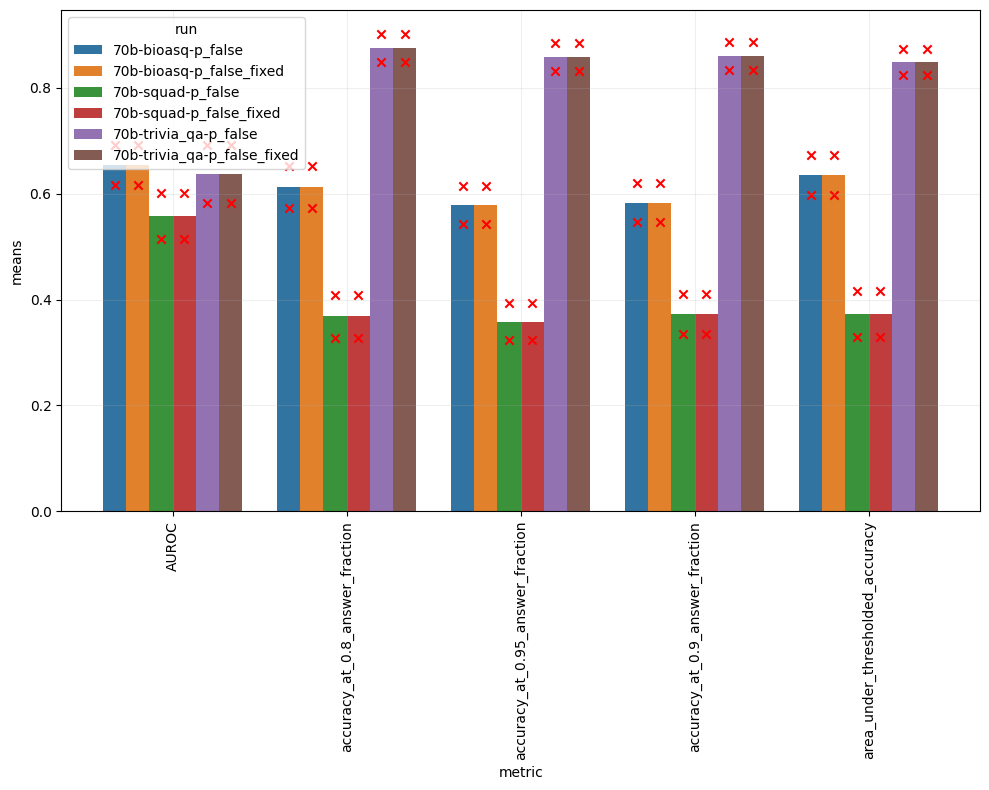

In [14]:
df2 = deepcopy(all_runs)
df2 = df2[all_runs.method == 'semantic_entropy_sum_cmean']
df2 = df2[all_runs.metric != 'mean_uncertainty']

df2 = df2.sort_values(['run', 'metric'])

fig, ax = plt.subplots(1, 1, figsize=(10, 8), sharey=True, dpi=100)

g = sns.barplot(
    x="metric",       # x variable name
    y="means",       # y variable name
    hue="run",  # group variable name
    data=df2,     # dataframe to plot
    ax=ax,
)

# https://stackoverflow.com/questions/72352491/how-to-plot-errorbars-on-seaborn-barplot
x_coords = [p.get_x() + 0.5 * p.get_width() for p in ax.patches]
y_coords = [p.get_height() for p in ax.patches]

for kind in ['low', 'high']:
    tmp = df2[kind].values
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    ax.scatter(x_coords[:-len(df2.run.unique())], tmp, c='red', marker='x')
ax.grid(zorder=-100, alpha=0.2)
# ax.set_ylim(0.3, 1)
plt.tight_layout()

/tmp/ipykernel_987668/3826733038.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
/tmp/ipykernel_987668/3826733038.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


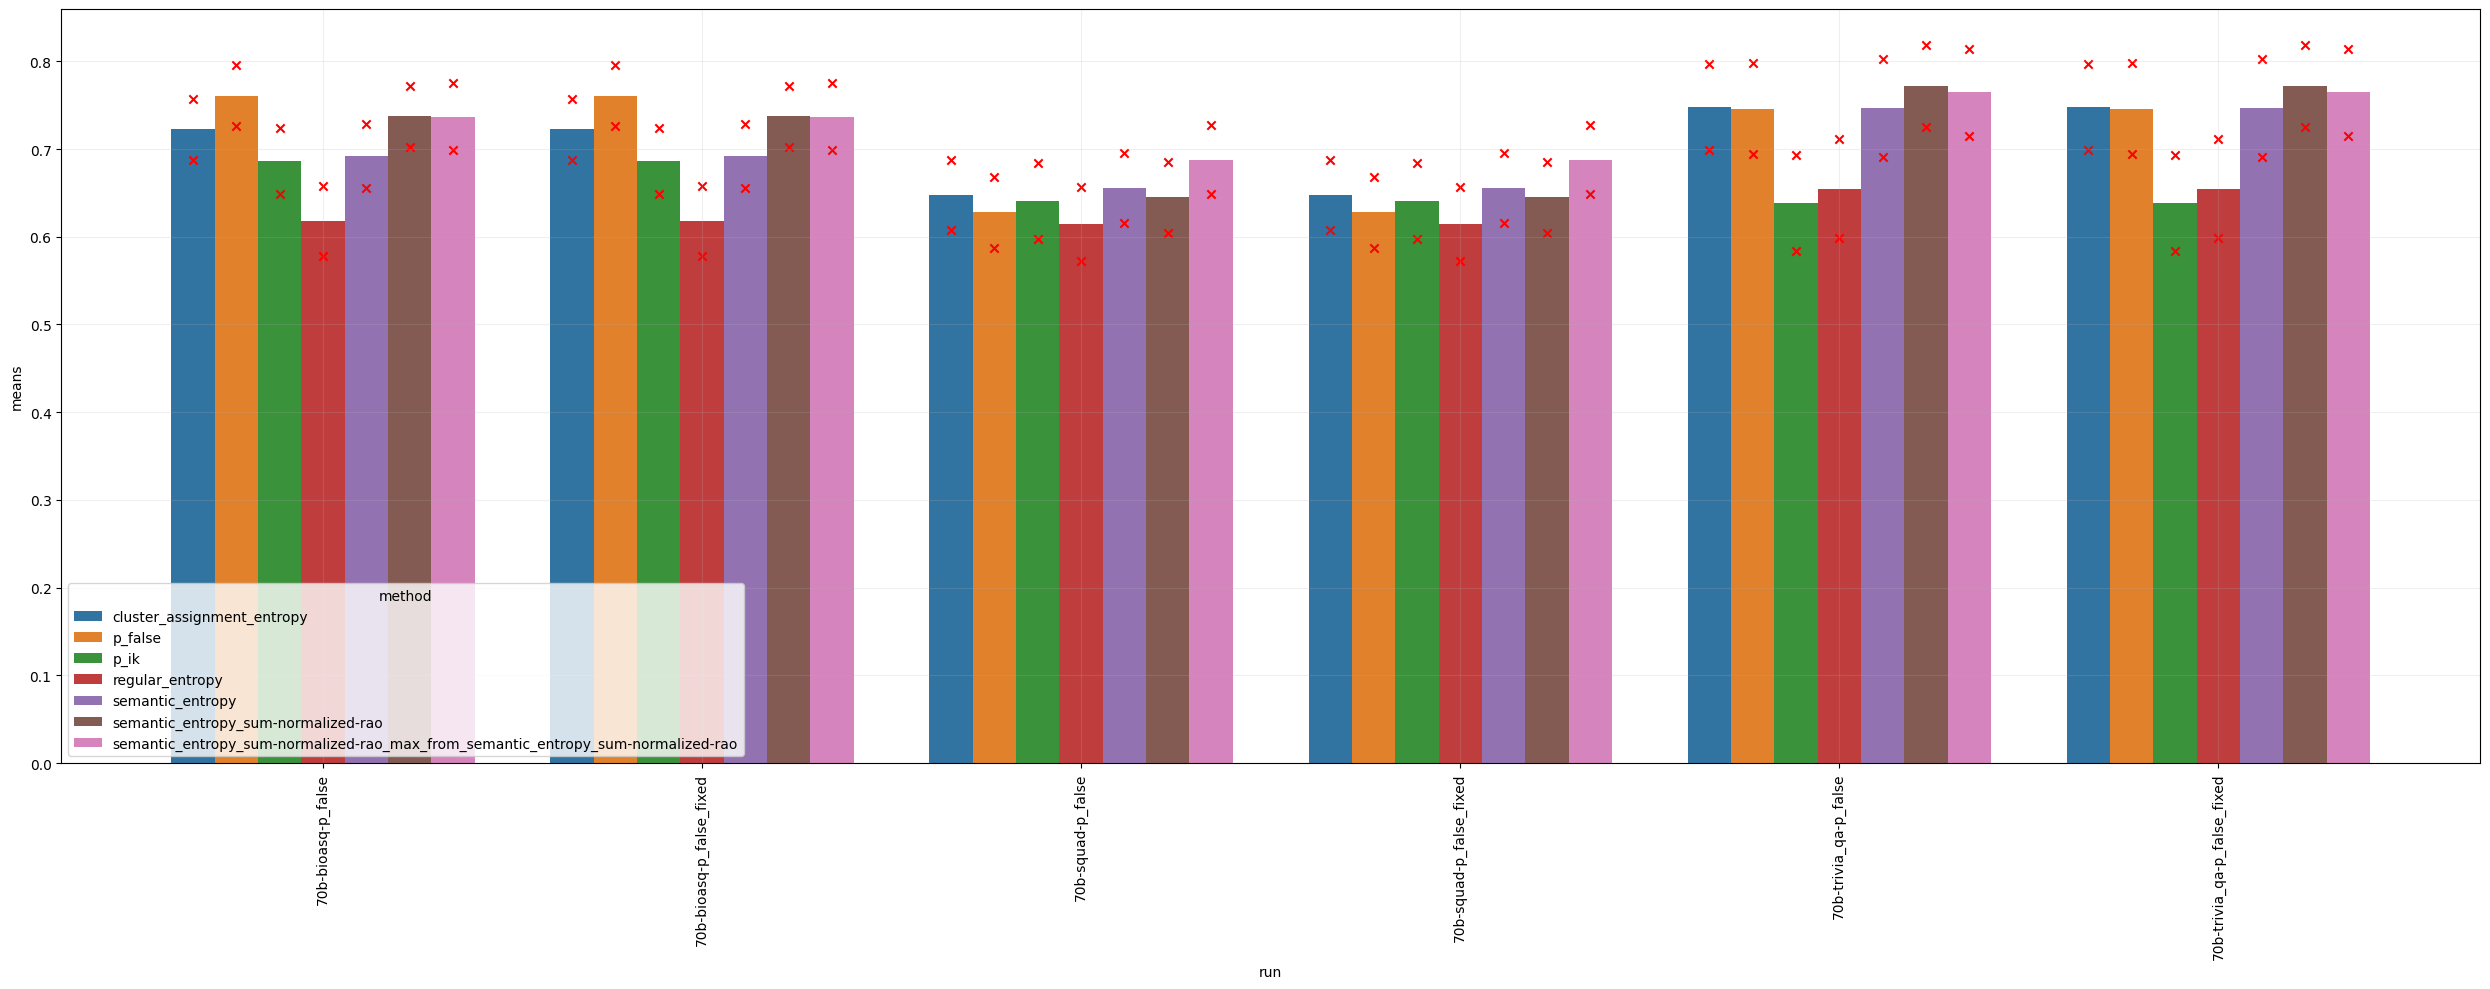

In [17]:
df2 = deepcopy(all_runs)
df2 = df2[df2.metric == 'AUROC']
# df2 = df2[df2.metric == 'area_under_thresholded_accuracy']
main_methods = ['cluster_assignment_entropy', 'regular_entropy', 'semantic_entropy', 'p_ik', 'p_false', 'semantic_entropy_sum-normalized-rao', 'semantic_entropy_sum-normalized-rao_max_from_semantic_entropy_sum-normalized-rao']

df2 = df2[df2.method.map(lambda x: x in main_methods)]
df2 = df2[df2.run.map(lambda x: '70b' in x)]
df2 = df2.sort_values(['method', 'run'])

fig, ax = plt.subplots(1, 1, figsize=(25, 10), sharey=True, dpi=100)

g = sns.barplot(
    x="run",       # x variable name
    y="means",       # y variable name
    hue="method",  # group variable name
    data=df2,     # dataframe to plot
    ax=ax,
)

# https://stackoverflow.com/questions/72352491/how-to-plot-errorbars-on-seaborn-barplot
x_coords = [p.get_x() + 0.5 * p.get_width() for p in ax.patches]
y_coords = [p.get_height() for p in ax.patches]

for kind in ['low', 'high']:
    tmp = df2[kind].values
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    ax.scatter(x_coords[:-len(df2.method.unique())], tmp, c='red', marker='x')
ax.grid(zorder=-100, alpha=0.2)
# ax.set_ylim(0.3, 1)
plt.tight_layout()

**Strict entailment with deberta seems clearly worse for long generations? but what about with llama? --> need other experiments to come in!**

In [23]:
tmp = all_runs.set_index('metric').loc['AUROC']
tmp.set_index('method').loc['p_false']

,means,low,high,base_method,run
method,,,,,
p_false,0.628022,0.587653,0.668391,p_false,70b-squad-p_false
p_false,0.628022,0.587653,0.668391,p_false,70b-squad-p_false_fixed
p_false,0.745686,0.693782,0.797591,p_false,70b-trivia_qa-p_false
p_false,0.745686,0.693782,0.797591,p_false,70b-trivia_qa-p_false_fixed
p_false,0.760960,0.726581,0.795339,p_false,70b-bioasq-p_false
p_false,0.760960,0.726581,0.795339,p_false,70b-bioasq-p_false_fixed


Ok nice! The AUROC does not care about the rescaling at all!

In [24]:
tmp = all_runs.set_index('metric').loc['area_under_thresholded_accuracy']
tmp.set_index('method').loc['p_false']

,means,low,high,base_method,run
method,,,,,
p_false,0.406816,0.364490,0.449142,p_false,70b-squad-p_false
p_false,0.406816,0.364490,0.449142,p_false,70b-squad-p_false_fixed
p_false,0.877415,0.858115,0.896715,p_false,70b-trivia_qa-p_false
p_false,0.877415,0.858115,0.896715,p_false,70b-trivia_qa-p_false_fixed
p_false,0.702547,0.668119,0.736975,p_false,70b-bioasq-p_false
p_false,0.702547,0.668119,0.736975,p_false,70b-bioasq-p_false_fixed


In [26]:
tmp = all_runs.set_index('metric').loc['accuracy_at_0.9_answer_fraction']
tmp.set_index('method').loc['p_false']

,means,low,high,base_method,run
method,,,,,
p_false,0.361111,0.324371,0.397851,p_false,70b-squad-p_false
p_false,0.361111,0.324371,0.397851,p_false,70b-squad-p_false_fixed
p_false,0.888889,0.863888,0.913890,p_false,70b-trivia_qa-p_false
p_false,0.888889,0.863888,0.913890,p_false,70b-trivia_qa-p_false_fixed
p_false,0.605556,0.567132,0.643979,p_false,70b-bioasq-p_false
p_false,0.605556,0.567132,0.643979,p_false,70b-bioasq-p_false_fixed


/tmp/ipykernel_987668/1375408283.py:2: RuntimeWarning: divide by zero encountered in log
  logy = np.log(y)


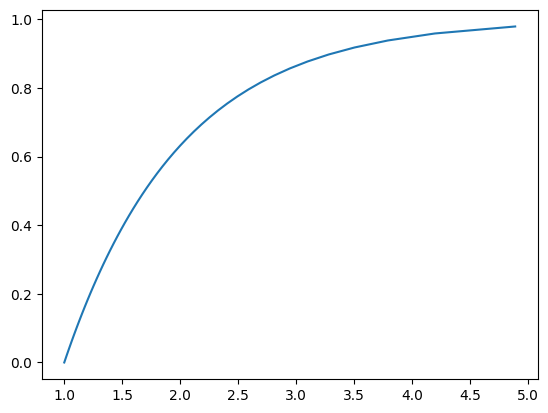

In [32]:
y = np.linspace(0, 1)
logy = np.log(y)

plt.plot(1 - logy, 1 - np.exp(logy))

we change from 1 - logy to  1- np.exp(1-logy))


it looks like auroc/AUC_thresholded do not care about such monotonous remapping